# 13 — unarXive Sentence Provenance Mapping

Builds a **sentence-level provenance mapping** between the v3 HuggingFace dataset and the original unarXive source papers.

**Output dataset schema:**

| Column | Description |
|--------|-------------|
| `sentence_id` | Row index in the v3 HF dataset |
| `sentence` | Sentence text |
| `move_sub_move_gemini` | Gemini Pro label |
| `paper_id` | unarXive paper ID (`_id` from `saier/unarXive_imrad_clf`) — null for synthetic |
| `paragraph_text` | The introduction paragraph the sentence was extracted from — null for synthetic |
| `source` | `unarxive` or `synthetic` |

**This dataset is published as a complementary resource** so researchers can recover the original introduction context for any v3 sentence.

**What comes next:** notebooks 12a/12b are re-run using only `source == 'unarxive'` sentences for the human annotation, giving epistemic grounding to real rather than synthetic examples.

## 1. Install & Setup

In [ ]:
!pip install -q datasets tqdm nltk huggingface_hub

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## 2. Configuration

In [ ]:
UNARXIVE_ID   = 'saier/unarXive_imrad_clf'
INTRO_LABEL   = 'i'

V3_DATASET_ID = 'stormsidali2001/IMRAD-introduction-sentences-moves-sub-moves-dataset'
MAPPING_REPO  = 'stormsidali2001/IMRAD-introduction-sentences-unarxive-mapping'

MIN_SENT_LEN  = 20

CHECKPOINT    = 'provenance_checkpoint.json'
OUTPUT_CSV    = 'v3_provenance_mapping.csv'

print(f'Source  : {UNARXIVE_ID}')
print(f'v3      : {V3_DATASET_ID}')
print(f'Publish : {MAPPING_REPO}')

Source  : saier/unarXive_imrad_clf
v3      : stormsidali2001/IMRAD-introduction-sentences-moves-sub-moves-dataset
Publish : stormsidali2001/IMRAD-introduction-sentences-unarxive-mapping


## 3. Load v3 Dataset → Build Lookup Set

Normalise every v3 sentence the same way the original pipeline did (`lower()` + collapse whitespace). The resulting set is ≤200k strings — negligible memory.

In [ ]:
import re
import pandas as pd
from datasets import load_dataset, Features, Value

def normalise(text):
    return re.sub(r'\s+', ' ', str(text).lower().strip())


features = Features({
    'sentence':             Value('string'),
    'move_sub_move_gemini': Value('string'),
})
v3_hf = load_dataset(V3_DATASET_ID, split='train', features=features)
v3_df = v3_hf.to_pandas()
v3_df.insert(0, 'sentence_id', range(len(v3_df)))   # stable row index = sentence_id
v3_df['_norm'] = v3_df['sentence'].apply(normalise)

# Build lookup: normalised sentence -> list of sentence_ids
# (the same sentence can appear multiple times in v3 due to data merging)
v3_lookup = {}
for _, row in v3_df.iterrows():
    norm = row['_norm']
    v3_lookup.setdefault(norm, []).append(row['sentence_id'])

print(f'v3 sentences       : {len(v3_df):,}')
print(f'Unique norm strings: {len(v3_lookup):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/75.1M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

v3 sentences       : 200,328
Unique norm strings: 199,744


## 4. Resume from Checkpoint (if any)

The checkpoint is a JSON file mapping `sentence_id → {paper_id, paragraph_text}`.  
If the Colab session dies mid-scan, re-run from this cell and the scan will skip already-matched sentences.

In [ ]:
import os, json

if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT) as f:
        # keys are stored as strings in JSON — convert back to int
        matches = {int(k): v for k, v in json.load(f).items()}
    print(f'Resumed: {len(matches):,} sentence_ids already matched.')
else:
    matches = {}   # sentence_id (int) -> {'paper_id': str, 'paragraph_text': str}
    print('No checkpoint. Starting fresh.')

No checkpoint. Starting fresh.


## 5. Stream unarXive → Build Sentence→Paper Mapping

For each introduction paragraph in `saier/unarXive_imrad_clf`:
1. Split into sentences with `nltk.sent_tokenize`.
2. Normalise and look up against the v3 set.
3. Record `sentence_id → {paper_id, paragraph_text}` for every match.

**First match wins** — if a sentence appears in multiple papers, only the first paper encountered is recorded (common for short, generic phrases; rare for full academic sentences).

In [ ]:
from nltk.tokenize import sent_tokenize
from tqdm.auto import tqdm

CHECKPOINT_EVERY = 50_000

ds = load_dataset(UNARXIVE_ID, split='train', streaming=True)

n_para       = 0
n_intro_para = 0

pbar = tqdm(desc='Scanning unarXive', unit='para')

for row in ds:
    if row.get('label', '') != INTRO_LABEL:
        n_para += 1
        pbar.update(1)
        continue

    n_intro_para += 1
    paper_id  = row.get('_id', '')
    paragraph = str(row.get('text', ''))

    for sent in sent_tokenize(paragraph):
        norm = normalise(sent)
        if len(norm) < MIN_SENT_LEN:
            continue
        if norm not in v3_lookup:
            continue
        for sid in v3_lookup[norm]:
            if sid not in matches:
                matches[sid] = {'paper_id': paper_id, 'paragraph_text': paragraph}

    n_para += 1
    pbar.update(1)

    if n_para % CHECKPOINT_EVERY == 0:
        with open(CHECKPOINT, 'w') as f:
            json.dump(matches, f)
        pbar.set_postfix({'intro_para': n_intro_para, 'matched': len(matches)})

pbar.close()

with open(CHECKPOINT, 'w') as f:
    json.dump(matches, f)

print(f'\nTotal paragraphs scanned : {n_para:,}')
print(f'Introduction paragraphs  : {n_intro_para:,}')
print(f'v3 sentences matched     : {len(matches):,}  ({100*len(matches)/len(v3_df):.1f}% of v3)')
print(f'v3 sentences unmatched   : {len(v3_df) - len(matches):,}  (synthetic)')

Scanning unarXive: 0para [00:00, ?para/s]


Total paragraphs scanned : 520,053
Introduction paragraphs  : 264,799
v3 sentences matched     : 34,641  (17.3% of v3)
v3 sentences unmatched   : 165,687  (synthetic)


## 6. Build Mapping DataFrame

In [8]:
rows = []
for _, row in v3_df.iterrows():
    sid  = int(row['sentence_id'])
    info = matches.get(sid)
    rows.append({
        'sentence_id':          sid,
        'sentence':             row['sentence'],
        'move_sub_move_gemini': row['move_sub_move_gemini'],
        'paper_id':             info['paper_id']       if info else None,
        'paragraph_text':       info['paragraph_text'] if info else None,
        'source':               'unarxive'             if info else 'synthetic',
    })

mapping_df = pd.DataFrame(rows)

print('Source distribution:')
print(mapping_df['source'].value_counts())
print(f'\nTotal rows: {len(mapping_df):,}')
mapping_df.head(3)

Source distribution:
source
synthetic    165687
unarxive      34641
Name: count, dtype: int64

Total rows: 200,328


,sentence_id,sentence,move_sub_move_gemini,paper_id,paragraph_text,source
0,0,We evaluate our approach of specializing docum...,-1.0,bf0ca256-8ca9-4d7a-a964-3f7967d11b3c,We evaluate our approach of specializing docum...,unarxive
1,1,Research papers in Papers with Code are labele...,-1.0,bf0ca256-8ca9-4d7a-a964-3f7967d11b3c,We evaluate our approach of specializing docum...,unarxive
2,2,We use these labels as aspects to specialize t...,-1.0,bf0ca256-8ca9-4d7a-a964-3f7967d11b3c,We evaluate our approach of specializing docum...,unarxive


## 7. Breakdown by Move

Source breakdown by top-level move:

  Move 0:  3,981 unarxive (7.1%)  52,487 synthetic (92.9%)  total=56,468
  Move 1:  1,488 unarxive (2.7%)  54,116 synthetic (97.3%)  total=55,604
  Move 2:  3,327 unarxive (5.8%)  54,330 synthetic (94.2%)  total=57,657


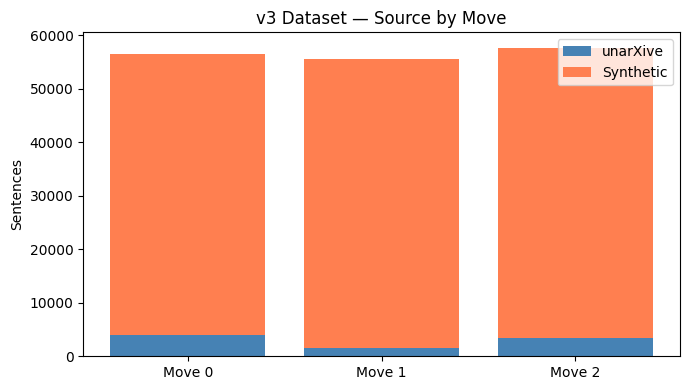

In [9]:
import matplotlib.pyplot as plt

def safe_int(x):
    try:
        return int(float(str(x).strip()))
    except (ValueError, TypeError):
        return -1

mapping_df['move'] = mapping_df['move_sub_move_gemini'].apply(safe_int)
valid_df = mapping_df[mapping_df['move'].isin([0, 1, 2])]

print('Source breakdown by top-level move:\n')
for move in [0, 1, 2]:
    sub   = valid_df[valid_df['move'] == move]
    total = len(sub)
    ux    = (sub['source'] == 'unarxive').sum()
    sy    = (sub['source'] == 'synthetic').sum()
    print(f'  Move {move}: {ux:6,} unarxive ({100*ux/total:.1f}%)  '
          f'{sy:6,} synthetic ({100*sy/total:.1f}%)  total={total:,}')

fig, ax = plt.subplots(figsize=(7, 4))
for i, move in enumerate([0, 1, 2]):
    sub = valid_df[valid_df['move'] == move]
    ux  = (sub['source'] == 'unarxive').sum()
    sy  = (sub['source'] == 'synthetic').sum()
    ax.bar(i, ux, label='unarXive'  if i == 0 else '', color='steelblue')
    ax.bar(i, sy, bottom=ux, label='Synthetic' if i == 0 else '', color='coral')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Move 0', 'Move 1', 'Move 2'])
ax.set_ylabel('Sentences')
ax.set_title('v3 Dataset — Source by Move')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save CSV to Drive

In [10]:
mapping_df.drop(columns=['move']).to_csv(OUTPUT_CSV, index=False)
print(f'Saved: {OUTPUT_CSV}')

Saved: v3_provenance_mapping.csv


## 9. Publish to Hugging Face

Authenticate, then push the mapping as a public complementary dataset.  
Run `huggingface-cli login` in a terminal first, or set `HF_TOKEN` as a Colab secret.

In [12]:
from datasets import Dataset
from huggingface_hub import login

login()   # enter your HF token when prompted

publish_df = mapping_df.drop(columns=['move'])
hf_dataset = Dataset.from_pandas(publish_df, preserve_index=False)
hf_dataset.push_to_hub(MAPPING_REPO, private=False)

print(f'Published: https://huggingface.co/datasets/{MAPPING_REPO}')

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/201 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   3%|3         |  557kB / 16.5MB            

Published: https://huggingface.co/datasets/stormsidali2001/IMRAD-introduction-sentences-unarxive-mapping
